In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline

# Baseline Figures Comparison

In [3]:
# Experiment Name and Locations
exp_1 = "tf-fc-ss-hemt_cu-xld400"
fname1 = PROJ_ROOT_PATH / "notebooks" / "experiments" / "historical" / "krinner" / exp_1 / f"{exp_1}.pkl"
pqfname1 =  PROJ_ROOT_PATH / "notebooks" / "experiments" / "historical" / "krinner" / exp_1/ f"PQ_{exp_1}.pkl"
df_1 =  pd.read_pickle(fname1)
df_pq_1 =  pd.read_pickle(pqfname1)
pq_1 = df_pq_1.iloc[0].tolist()
title_1 = "a) TF-FC | SS cabling | XLD400"

exp_2 = "tf-fc-delft-hemt_cu-xld400"
fname2 =  PROJ_ROOT_PATH / "notebooks" / "experiments" /"historical" / "krinner" / exp_2 / f"{exp_2}.pkl"
pqfname2 =  PROJ_ROOT_PATH / "notebooks" / "experiments" / "historical" / "krinner"  / exp_2 / f"PQ_{exp_2}.pkl"
df_2 =  pd.read_pickle(fname2)
df_pq_2 =  pd.read_pickle(pqfname2)
pq_2 = df_pq_2.iloc[0].tolist()
title_2 = "b) TF-FC | Cri/oFlex cabling | XLD400"

In [4]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white' 
fallback_hatch = '//'  

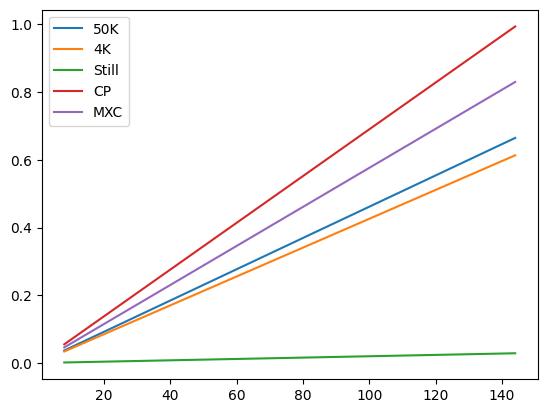

In [6]:
# Get names of temperature stages
temp_stage = df_1.index.tolist()

# Determine how many qubits the heat loads are for
no_of_pq = df_pq_1.loc["PQ"].to_numpy()

# Normalized heat load rates per qubit
values_1 = df_1["Total"].to_numpy()/min(no_of_pq) # values normalized wrt cooling powers

# Y-axis limit
qubit_nos = np.linspace(8, int(min(no_of_pq)), int(min(no_of_pq)/8))
for i,val in enumerate(values_1):
    plt.plot(qubit_nos, qubit_nos*val, label=temp_stage[i])
plt.legend()

In [7]:
values_1

array([0.00461667, 0.00426017, 0.0002    , 0.00690231, 0.00576416])

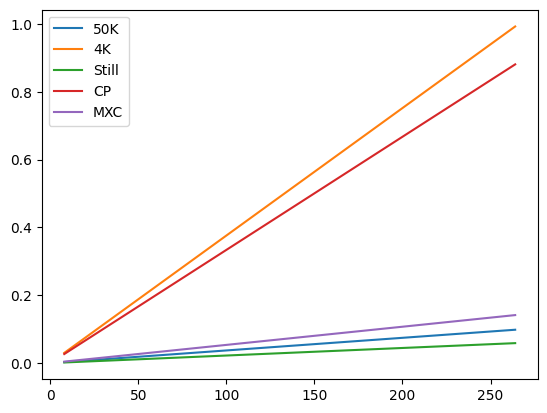

In [8]:
temp_stage = df_2.index.tolist()
no_of_pq = df_pq_2.loc["PQ"].to_numpy()
values_2 = df_2["Total"].to_numpy()/min(no_of_pq) # values normalized wrt cooling powers
qubit_nos = np.linspace(8,264,33)
for i,val in enumerate(values_2):
    plt.plot(qubit_nos, qubit_nos*val, label=temp_stage[i])
plt.legend()

In [9]:
values_2


array([0.0003725 , 0.00376017, 0.00022275, 0.00333686, 0.00053612])